In [1]:
# from jax.lib import xla_bridge
# import jax
# print(xla_bridge.get_backend().platform)
# # name = "cuDNN"
# jax._src.lib.cuda_versions.cudnn_get_version()
# # jax._src.lib.cuda_versions.cudnn_build_version()
# jax.default_device = jax.devices("gpu")[0]

# # # bp.math.set_platform("cpu")
# import os
# # if bp.math.get_platform() == 'cpu':
# threads = os.cpu_count()//10
# os.environ["XLA_FLAGS"] = '--xla_force_host_platform_device_count=' + str(threads)
# print(os.environ["XLA_FLAGS"])

In [2]:
import brainpy as bp
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jax
import jax.numpy as jnp
import sys
import os

src_dir = os.path.abspath(os.path.join('../../../'))
sys.path.insert(0, src_dir)
import src
# plt.style.use('../../../foresight.mplstyle')


/home/brendan/OneDrive/Masters/Code/Vortices/Julia/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# bp.math.set_dt(0.05) # Check sims look similar with smaller timestep

# Parameterizing by mass means the balance condition is independent of sigma
# zeta_e = (delta*omega_ie)/(gamma*omega_ee)
# zeta_i = (delta*omega_ii)/(gamma*omega_ei)

# * If delta == gamma (population size exactly balanced by synaptic weight), zeta balance
#   reduces to omega_ie == omega_ee and omega_ii == omega_ei

N_e = 4000
J_e = 0.0008 # Microsiemens
delta = 4.0 # 2.9
nu = 10 # Preserve; the minimum required for spontaneous spiking
n_ext = 70

# ? Notes:
# - A positive (real part) eigenvalue means the system is unstable
# - Two negative eigenvalues means excitatory bursts are immediately quenched
# - Two complex eigenvalue means oscillation (PING). More complex means sparser exc. activity?

# - Higher cross-coupling terms make the excitatory activity sparser, oscillations stronger
# - Increasing omega_ee does not increase the frequency of oscillations, just sharpens them
# - Increasing omega_ii sharpens the oscillations
#!- Increasing background drive increases frequency... makes sense, reduces recovery time of
#   exc. pop
# - Adaptation doesn't seem to induce theta oscillations without the spatial component... so
#   we should look at adding a central stimulus to the spatial model, like shencong.

# ! Exact frequency fo gamma oscillation depends on E and I timescales


# ! Note: All of the above is true in a general sence, but the eigenvalues don't match the
# thresholds exactly due to filter effects (e.g. inhibitory synaptic decay time constant)
alpha = 0.06 # This alpha actually controls the frequency of ping; smaller alpha, higher frequency...
omega_ee = 0.30*alpha
omega_ie = 0.47*alpha
omega_ei = 0.37*alpha
omega_ii = 0.65*alpha


# * We suppose the k1 < omega_ei * delta * omega_ie < k2 gives some sort of criterion for
#   the presence of gamma. Confirm

# * What are the eigenvalues of the weight matrix?
W = np.array([[omega_ee, omega_ei], [-omega_ie*delta, -omega_ii*delta]]) # ! The presence of oscillations seems independent of delta? Just the strength is controlled by delta.
tr = np.trace(W)
eigvals = np.linalg.eigvals(W)
det = np.linalg.det(W)
frob = np.linalg.norm(W, ord='fro')
print('Trace:', tr)
print('Eigenvalues:', eigvals)
print('Det:', det)
print('Frobenius norm:', frob)

Trace: -0.138
Eigenvalues: [ 0.00216769 -0.14016769]
Det: -0.0003038400000000012
Frobenius norm: 0.19461932072638624


In [ ]:
from src.models.FNS import FNS
@jax.jit
def jittest(nu, J_e, delta, seed):
    FNSnet = FNS(N_e = N_e,
        J_e = J_e, # Jaxable
        nu = nu, # Jaxable
        n_ext = n_ext,
        delta=delta, # Jaxable
        omega_ee=omega_ee,
        omega_ei=omega_ei,
        omega_ie=omega_ie,
        omega_ii=omega_ii,
        key=jax.random.PRNGKey(seed)) # Jaxable
    # * And simulate
    runner = bp.DSRunner(FNSnet, monitors=['E.spike'], numpy_mon_after_run=False)
    runner.run(duration=50.)
    return runner.mon['E.spike']


In [5]:
out = jittest(300, 0.0001, 3.9, 49)
out

Predict 500 steps: :   0%|          | 0/500 [00:00<?, ?it/s]


Array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], dtype=bool)

In [6]:
from src.models.FNS import FNS
# import line_profiler

FNSnet = FNS(N_e = N_e,
        J_e = J_e,
        nu = nu,
        n_ext = n_ext,
        delta=delta,
        omega_ee=omega_ee,
        omega_ei=omega_ei,
        omega_ie=omega_ie,
        omega_ii=omega_ii,
        key=jax.random.PRNGKey(42))


# %load_ext line_profiler
# %lprun -f FNSnet.__init__ build()

In [7]:
print("Num. Exc.:");print(np.prod(FNSnet.E.size))
print("Num. Inh.:");print(np.prod(FNSnet.I.size))
# thr_e, thr_i = FNSnet.nu_n_ext_thresh()
# print("Thresholds:");print(thr_e, thr_i)


Num. Exc.:
4000
Num. Inh.:
1000


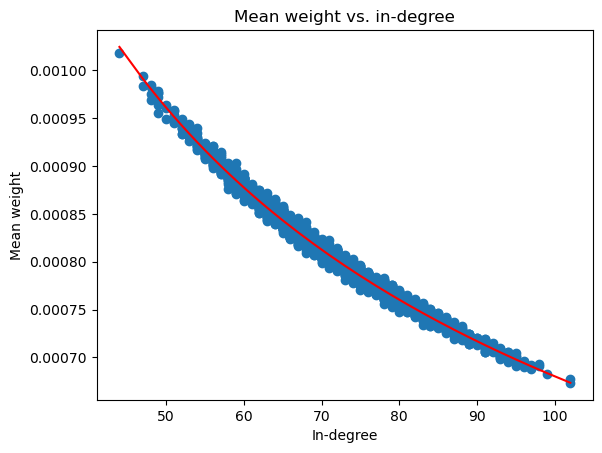

E2E in-degree: 72.0 (mean), 72.0 (expected)
E2I in-degree: 88.0 (mean), 88.8 (expected)
I2E in-degree: 28.0 (mean), 28.2 (expected)
I2I in-degree: 39.0 (mean), 39.0 (expected)
External in-degree (Exc.): 70.0 (mean)
External in-degree (Inh.): 69.8 (mean)


In [8]:
def mean_weights(proj):
    """
    Calculate the mean input weight for each postsynaptic neuron.
    That is, for each post-syn index i, we compute:
        mean_weights[i] = (sum of weights of all edges leading to i) / (number of edges leading to i).
    """
    # Number of post-synaptic neurons
    M = jnp.prod(jnp.array(proj.post.size))

    # 'indices' is a 1D array listing which post-syn neuron each edge connects to
    indices = jnp.array(proj.comm.indices)
    # 'weight' holds the corresponding weight for each edge in the same order
    weights = jnp.array(proj.comm.weight)

    # 1) in-degree count: how many edges lead to each post-syn i
    in_degs = jnp.bincount(indices, length=M)

    # 2) sum of weights leading to each post-syn i
    sum_w = jnp.bincount(indices, weights=weights, length=M)

    # 3) safely divide sum_w[i] by in_degs[i], handling the case in_degs[i] = 0
    mean_w = jnp.where(in_degs > 0, sum_w / in_degs, 0.0)
    return mean_w
mean_ws = mean_weights(FNSnet.E2E.proj)
N = FNSnet.E2E.proj.post.size
ks = src.utils.indegrees_static(FNSnet.E2E.proj.comm.indices, N)
plt.scatter(ks, mean_ws)
a, b = np.polyfit(1/np.sqrt(ks), mean_ws, 1)
sks = np.sort(ks)
plt.plot(sks, a/np.sqrt(sks) + b, 'r')
plt.xlabel('In-degree')
plt.ylabel('Mean weight')
plt.title('Mean weight vs. in-degree')
plt.show()


k = src.utils.indegree(FNSnet.E2E.proj)
k_hat = FNSnet.expected_indegree("ee")
print(f"E2E in-degree: {k:.1f} (mean), {k_hat:.1f} (expected)")
k = src.utils.indegree(FNSnet.E2I.proj)
k_hat = FNSnet.expected_indegree("ei")
print(f"E2I in-degree: {k:.1f} (mean), {k_hat:.1f} (expected)")
k = src.utils.indegree(FNSnet.I2E.proj)
k_hat = FNSnet.expected_indegree("ie")
print(f"I2E in-degree: {k:.1f} (mean), {k_hat:.1f} (expected)")
k = src.utils.indegree(FNSnet.I2I.proj)
k_hat = FNSnet.expected_indegree("ii")
print(f"I2I in-degree: {k:.1f} (mean), {k_hat:.1f} (expected)")

# Print the mean number of external synapses
k_ext = src.utils.indegree(FNSnet.ext2E.proj)
print(f"External in-degree (Exc.): {k_ext:.1f} (mean)")
k_ext = src.utils.indegree(FNSnet.ext2I.proj)
print(f"External in-degree (Inh.): {k_ext:.1f} (mean)")

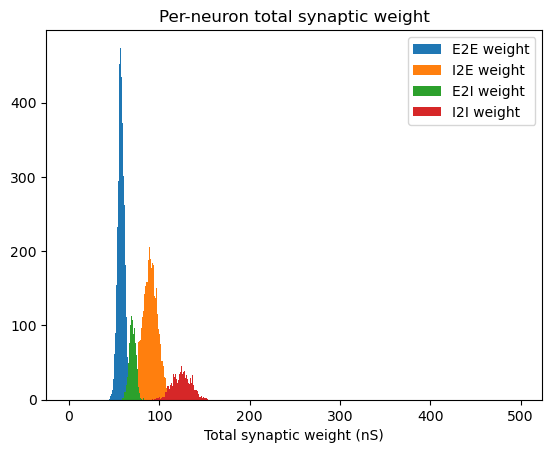

Sum of weights to average neuron:
E2E: 57.59074878739193 (nS)
E2I: 70.42782237182837 (nS)
I2E: 89.60657793172868 (nS)
I2I: 124.83176964335144 (nS)

IE ratio (Exc.): 1.5559196540841957
IE ratio (Inh.): 1.772478055395406

Expected IE ratio (Exc.): 1.5666666666666667
Expected IE ratio (Inh.): 1.756756756756757


In [9]:
if True:
    # * Calculate the per-neuron EI balance
    # DONT USE REQUIRES, SINCE THAT REBUILDS THE ARRAY
    # ? How to peroperly check the balance of weights?
    I2E = bp.connect.csr2coo((FNSnet.I2E.proj.comm.indices, FNSnet.I2E.proj.comm.indptr))
    E2E = bp.connect.csr2coo((FNSnet.E2E.proj.comm.indices, FNSnet.E2E.proj.comm.indptr))
    E2I = bp.connect.csr2coo((FNSnet.E2I.proj.comm.indices, FNSnet.E2I.proj.comm.indptr))
    I2I = bp.connect.csr2coo((FNSnet.I2I.proj.comm.indices, FNSnet.I2I.proj.comm.indptr))
    w_I2E = FNSnet.I2E.proj.comm.weight
    w_E2E = FNSnet.E2E.proj.comm.weight
    w_E2I = FNSnet.E2I.proj.comm.weight
    w_I2I = FNSnet.I2I.proj.comm.weight
    assert len(I2E[0]) == len(w_I2E)

    Ne = np.prod(FNSnet.E.size)
    Ni = np.prod(FNSnet.I.size)
    bin_w_E2E = np.bincount(E2E[1], weights=w_E2E, minlength=Ne)
    bin_w_I2E = np.bincount(I2E[1], weights=w_I2E, minlength=Ne)
    bin_w_E2I = np.bincount(E2I[1], weights=w_E2I, minlength=Ni)
    bin_w_I2I = np.bincount(I2I[1], weights=w_I2I, minlength=Ni)
    bins = np.arange(0, 500, 1)
    plt.hist(bin_w_E2E*1000, bins=bins, label="E2E weight")
    plt.hist(bin_w_I2E*1000, bins=bins, label="I2E weight")
    plt.hist(bin_w_E2I*1000, bins=bins, label="E2I weight")
    plt.hist(bin_w_I2I*1000, bins=bins, label="I2I weight")
    plt.legend()
    plt.title("Per-neuron total synaptic weight")
    plt.xlabel("Total synaptic weight (nS)")
    plt.show()

    # plt.scatter(bin_w_E2E, bin_w_I2E)
    # plt.show()

    # plt.hist(bin_w_E2E/bin_w_I2E, bins=50)
    # plt.show()

    # * Print sum of weights in table
    print("Sum of weights to average neuron:")
    print("E2E:", np.mean(bin_w_E2E)*1000, "(nS)") # Should be approx 2100
    print("E2I:", np.mean(bin_w_E2I)*1000, "(nS)") # approx 3800
    print("I2E:", np.mean(bin_w_I2E)*1000, "(nS)") # 5800
    print("I2I:", np.mean(bin_w_I2I)*1000, "(nS)") # 8100

    # * Calculate an IE ratio for each population defined as the ratio of average total incoming
    #   inhibitory synaptic strength to average total incoming excitatory synaptic strength for
    #   a specific neuron type
    print("")
    IE_e, IE_i = FNSnet.calculate_zeta()
    print("IE ratio (Exc.):", IE_e)
    print("IE ratio (Inh.):", IE_i)

    print("")
    IE_e_hat, IE_i_hat = FNSnet.expected_zeta()
    print("Expected IE ratio (Exc.):", IE_e_hat)
    print("Expected IE ratio (Inh.):", IE_i_hat)
    w_E2E

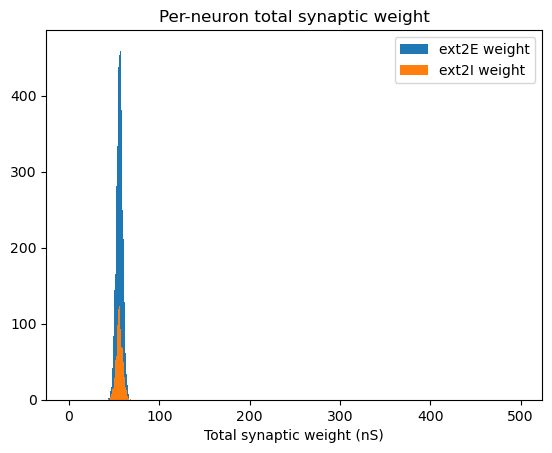

Sum of weights to average neuron (from external):
ext2E: 55.97207052912563 (nS)
ext2I: 55.877562224748544 (nS)


In [10]:
if True:
    # * As previous cell, but for external pop
    ext2E = bp.connect.csr2coo((FNSnet.ext2E.proj.comm.indices, FNSnet.ext2E.proj.comm.indptr))
    ext2I = bp.connect.csr2coo((FNSnet.ext2I.proj.comm.indices, FNSnet.ext2I.proj.comm.indptr))
    w_ext2E = FNSnet.ext2E.proj.comm.weight
    w_ext2I = FNSnet.ext2I.proj.comm.weight
    assert len(ext2E[0]) == len(w_ext2E)

    bin_w_ext2E = np.bincount(ext2E[1], weights=w_ext2E, minlength=Ne)
    bin_w_ext2I = np.bincount(ext2I[1], weights=w_ext2I, minlength=Ni)
    plt.hist(bin_w_ext2E*1000, bins=bins, label="ext2E weight")
    plt.hist(bin_w_ext2I*1000, bins=bins, label="ext2I weight")
    plt.legend()
    plt.title("Per-neuron total synaptic weight")
    plt.xlabel("Total synaptic weight (nS)")
    plt.show()

    # plt.scatter(bin_w_ext2E, bin_w_ext2I)
    # plt.show()

    # plt.hist(bin_w_ext2E/bin_w_ext2I, bins=50)
    # plt.show()

    print("Sum of weights to average neuron (from external):")
    print("ext2E:", np.mean(bin_w_ext2E)*1000, "(nS)") # Should be approx 1000
    print("ext2I:", np.mean(bin_w_ext2I)*1000, "(nS)") # approx 1000


In [11]:
# * No per-neuron balance
# ! xx No common-neighbour property
# ! xx No reverse pooling or lognormal coupling weights
bp.reset_state(FNSnet)
# * Simulate
# I = np.array(FNSnet.E.V.value)
# I[:] = 0.0
# i = I.reshape(*FNSnet.E.size)
# i[0:25, 0:25] = 0.0

runner = bp.DSRunner(FNSnet, monitors=['E.V', 'I.V', 'E.spike', 'I.spike','E.input', 'I.input'])# , inputs = [('Ein.input', I)])
runner.run(duration=5000.)

# t = runner.mon['ts'].view()
# X = runner.mon['E.spike'].view()

Predict 50000 steps: : 100%|██████████| 50000/50000 [00:23<00:00, 2100.37it/s]


In [12]:
def plot_trace_with_distribution(runner, neuron_idx=0, pop_type='E', n_bins=50, dt=25.0, figsize=(12, 6), cmap='binary'):
    """
    Plot a single neuron's voltage trace with a histogram distribution at each time step in the background.
    Uses JAX for fast histogram computation with temporal binning.

    Parameters:
    -----------
    runner : bp.DSRunner
        The runner object after simulation
    neuron_idx : int
        Index of the neuron to highlight with a trace
    pop_type : str
        'E' for excitatory neurons or 'I' for inhibitory neurons
    n_bins : int
        Number of voltage bins for the histogram
    dt : float
        Time bin size in ms - data points within this window will be combined
    figsize : tuple
        Size of the figure
    cmap : str
        Colormap for the histogram
    """
    import matplotlib.pyplot as plt
    import jax
    import jax.numpy as jnp
    import numpy as np

    fig, ax = plt.subplots(figsize=figsize)

    # Get the right population data and convert to JAX array
    if pop_type == 'E':
        V_full = jnp.asarray(runner.mon['E.V'])  # Shape should be (time_steps, n_neurons)
        title = f"Distribution of Excitatory Population Voltages (neuron #{neuron_idx} highlighted)"
    else:
        V_full = jnp.asarray(runner.mon['I.V'])  # For inhibitory population
        title = f"Distribution of Inhibitory Population Voltages (neuron #{neuron_idx} highlighted)"

    # Time points
    t_full = jnp.asarray(runner.mon.ts)

    # Apply temporal binning
    if dt > (t_full[1] - t_full[0]):
        # Calculate number of time points per bin
        points_per_bin = int(dt / (t_full[1] - t_full[0]))

        # Calculate number of bins needed
        n_bins_time = len(t_full) // points_per_bin
        if n_bins_time == 0:
            n_bins_time = 1  # At least one bin

        # Reshape the voltage data for binning
        # Only take complete bins
        V_reshaped = V_full[:n_bins_time*points_per_bin].reshape(n_bins_time, points_per_bin, -1)

        # Average within each time bin
        V = jnp.mean(V_reshaped, axis=1)

        # Create new time array with bin centers
        t_edges = t_full[:n_bins_time*points_per_bin:points_per_bin]
        if len(t_edges) > 1:
            bin_width = t_edges[1] - t_edges[0]
            t = t_edges + bin_width/2
        else:
            t = t_edges
    else:
        # No temporal binning needed
        V = V_full
        t = t_full

    # Find voltage range for consistent binning across all time steps
    v_min, v_max = jnp.min(V), jnp.max(V)
    bins = jnp.linspace(v_min, v_max, n_bins+1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Define JAX-compatible histogram function
    @jax.jit
    def compute_histogram(voltages):
        # Convert voltages to bin indices
        indices = jnp.clip(jnp.floor((voltages - v_min) / (v_max - v_min) * n_bins).astype(jnp.int32), 0, n_bins-1)
        # Count occurrences in each bin
        counts = jnp.zeros(n_bins, dtype=jnp.int32)
        counts = counts.at[indices].add(1)
        return counts

    # Vectorize the histogram computation over time steps
    compute_histograms = jax.vmap(compute_histogram)

    # Compute histograms for all time steps at once
    hist_data = compute_histograms(V)

    # Normalize each histogram row for better visibility
    hist_max = jnp.max(hist_data, axis=1, keepdims=True)
    hist_max = jnp.where(hist_max == 0, 1.0, hist_max)  # Avoid division by zero
    hist_norm = hist_data / hist_max

    # Convert back to numpy for matplotlib
    hist_norm = jnp.transpose(hist_norm).block_until_ready()

    # Plot the distribution over time as a 2D histogram/heatmap
    im = ax.pcolormesh(
        t,
        bin_centers,
        hist_norm,
        cmap=cmap,
        alpha=0.7
    )

    # Plot single neuron trace on top - use original high-resolution data for the trace
    ax.plot(t_full, V_full[:, neuron_idx], color='red', lw=1.5, label=f'Neuron {neuron_idx}')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, label='Normalized Neuron Count')

    # Set labels and title
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Membrane Potential (mV)')
    ax.set_title(f"{title} [dt={dt}ms]")
    ax.legend(loc='lower right')

    plt.tight_layout()
    return fig

In [ ]:
ve, vi = FNSnet.subthreshold_equilibrium_potential()
print("Steady-state membrane potential (Exc.):", ve)
print("Steady-state membrane potential (Inh.):", vi)
mve = np.mean(runner.mon['E.V'])
mvi = np.mean(runner.mon['I.V'])
print("Mean membrane potential (Exc.):", mve)
print("Mean membrane potential (Inh.):", mvi)

# Plot the distribution over time for excitatory population with neuron #10 highlighted
plot_trace_with_distribution(runner, neuron_idx=10, pop_type='E', n_bins=200)
plt.gca().set_xlim(0, 1000)
thr_e = FNSnet.E.V_th
plt.axhline(thr_e, color='black', linestyle='--', lw=1.5)
# Add dashed lines showing threshold

# Plot for inhibitory population
plot_trace_with_distribution(runner, neuron_idx=10, pop_type='I', n_bins=200)
plt.gca().set_xlim(0, 1000)
thr_i = FNSnet.I.V_th
plt.axhline(thr_i, color='black', linestyle='--', lw=1.5)


Steady-state membrane potential (Exc.): -55.90946107784431
Steady-state membrane potential (Inh.): -59.90432
Mean membrane potential (Exc.): -57.922836
Mean membrane potential (Inh.): -59.13994


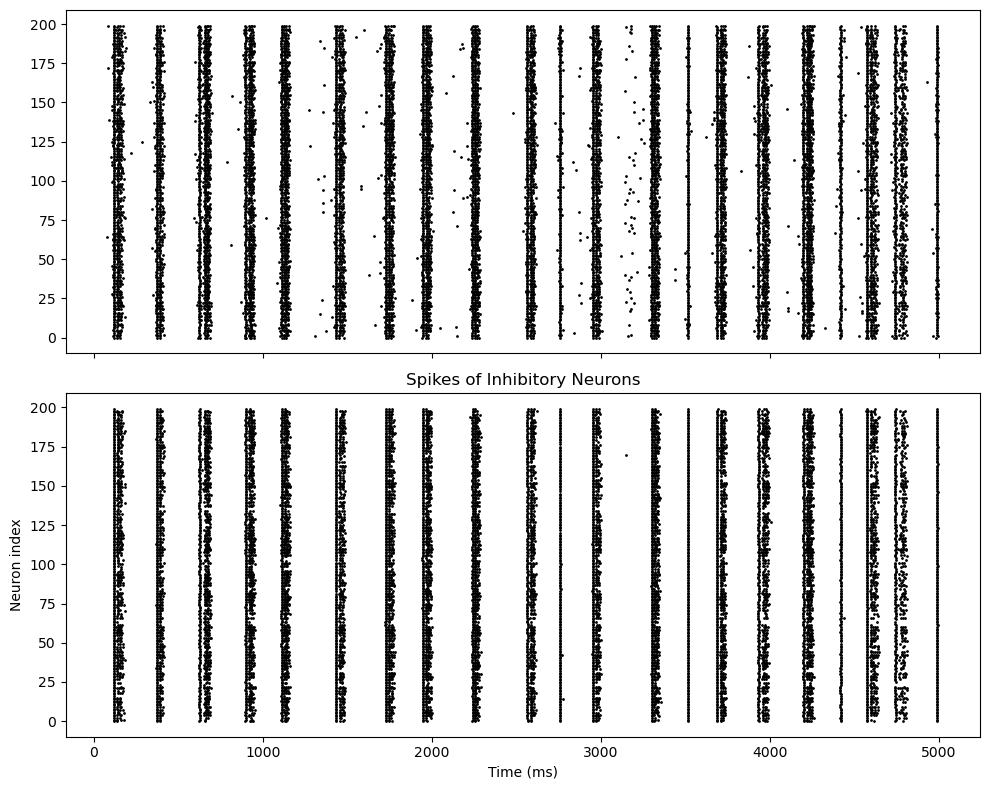

In [ ]:
# Create a figure and two subplots (stacked vertically)
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot the raster for excitatory neurons on the first subplot.
bp.visualize.raster_plot(runner.mon["ts"], runner.mon["E.spike"][:, ::20],
                           title="Spikes of Excitatory Neurons", ax=axs[0])
# Plot the raster for inhibitory neurons on the second subplot.
bp.visualize.raster_plot(runner.mon["ts"], runner.mon["I.spike"][:, ::5],
                           title="Spikes of Inhibitory Neurons", ax=axs[1])

plt.tight_layout()
plt.show()

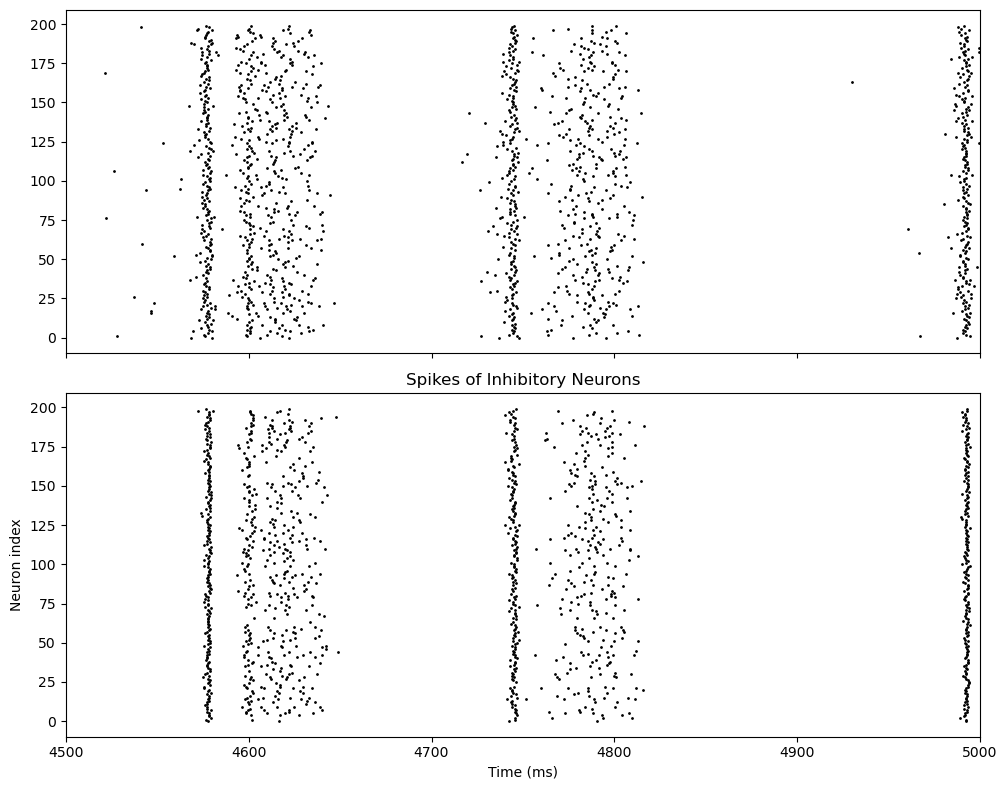

In [ ]:
# Create a figure and two subplots (stacked vertically)
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)


# Plot the raster for excitatory neurons on the first subplot.
bp.visualize.raster_plot(runner.mon["ts"], runner.mon["E.spike"][:, ::20],
                           title="Spikes of Excitatory Neurons", ax=axs[0])
# Plot the raster for inhibitory neurons on the second subplot.
bp.visualize.raster_plot(runner.mon["ts"], runner.mon["I.spike"][:, ::5],
                           title="Spikes of Inhibitory Neurons", ax=axs[1])

plt.tight_layout()
axs[0].set_xlim(4500, 5000)
axs[1].set_xlim(4500, 5000)
plt.show()

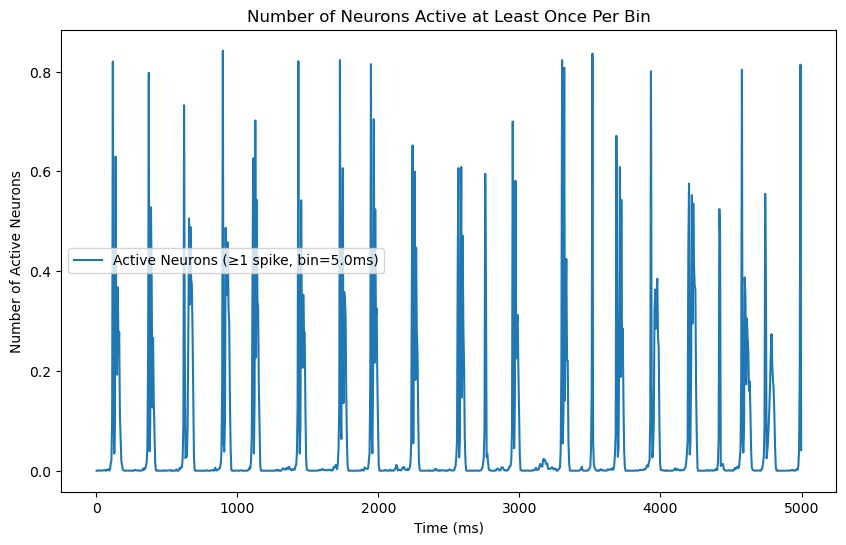

In [ ]:
# * Produce a plot of the number of neurons active at any given point in time

time = runner.mon["ts"]
spikes = runner.mon["E.spike"]  # shape: (time_steps, num_neurons), 1 if neuron spiked, else 0

bin_size = 5.0
time_ix = jnp.floor((time - time[0]) / bin_size).astype(int)
unique_bins = jnp.arange(time_ix.min(), time_ix.max() + 1)

binned_time = []
binned_active = []

for b in unique_bins:
    bin_mask = (time_ix == b)
    # Determine which neurons spiked at least once in this bin
    active_in_bin = jnp.any(spikes[bin_mask], axis=0)
    # Count how many neurons were active
    active_count = jnp.sum(active_in_bin)
    # Average time in this bin
    avg_t = jnp.mean(time[bin_mask])

    binned_time.append(avg_t)
    binned_active.append(active_count)

binned_time = jnp.array(binned_time)
binned_active = jnp.array(binned_active)
binned_prop_active = binned_active / spikes.shape[1]  # Normalize by number of neurons

plt.figure(figsize=(10, 6))
plt.plot(binned_time, binned_prop_active, label=f"Active Neurons (≥1 spike, bin={bin_size}ms)")
plt.xlabel("Time (ms)")
plt.ylabel("Number of Active Neurons")
plt.title("Number of Neurons Active at Least Once Per Bin")
plt.legend()
plt.show()



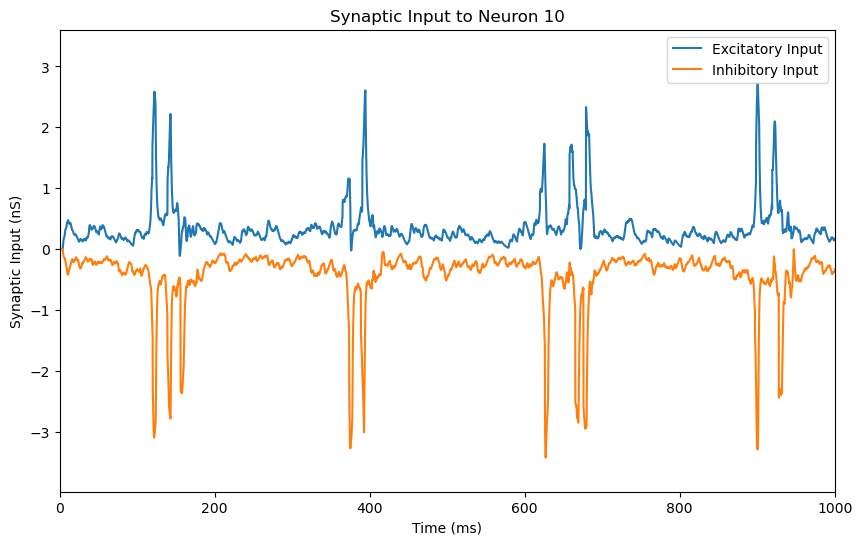

In [ ]:
# * Plot synaptic input for a sample neuron
n = 10
Ein = runner.mon['E.input'][:, n]
Iin = -runner.mon['I.input'][:, n]

plt.figure(figsize=(10, 6))
plt.plot(runner.mon.ts, Ein, label='Excitatory Input')
plt.plot(runner.mon.ts, Iin, label='Inhibitory Input')
plt.xlabel("Time (ms)")
plt.ylabel("Synaptic Input (nS)")
plt.title(f"Synaptic Input to Neuron {n}")
plt.legend()
plt.gca().set_xlim(0, 1000)
plt.show()


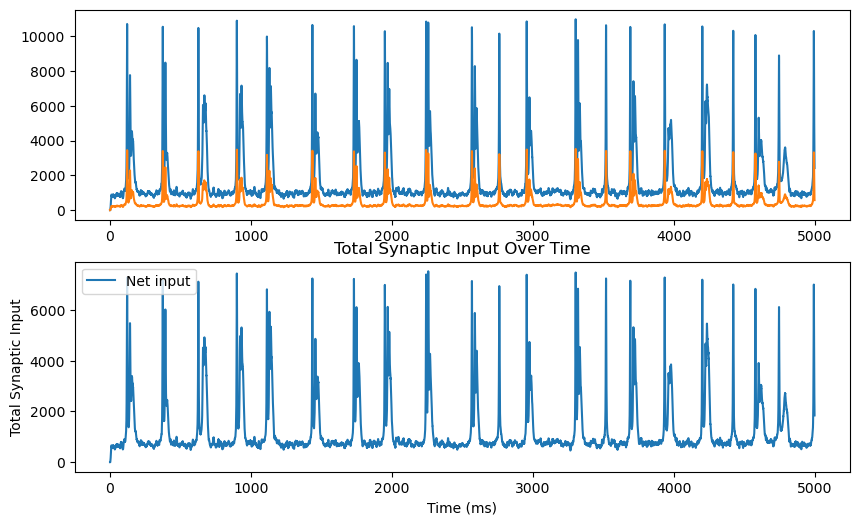

In [ ]:
# * Plot the sum of synaptic input across time

Ein = runner.mon['E.input']
Iin = runner.mon['I.input']
Einput = jnp.sum(Ein, axis=1)
Iinput = jnp.sum(Iin, axis=1)
input = Einput - Iinput
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(runner.mon.ts, Einput, label='E input')
plt.plot(runner.mon.ts, Iinput, label='I input')
plt.subplot(2, 1, 2)
plt.plot(runner.mon.ts, input, label='Net input')
plt.xlabel("Time (ms)")
plt.ylabel("Total Synaptic Input")
plt.title("Total Synaptic Input Over Time")
plt.legend()
plt.show()


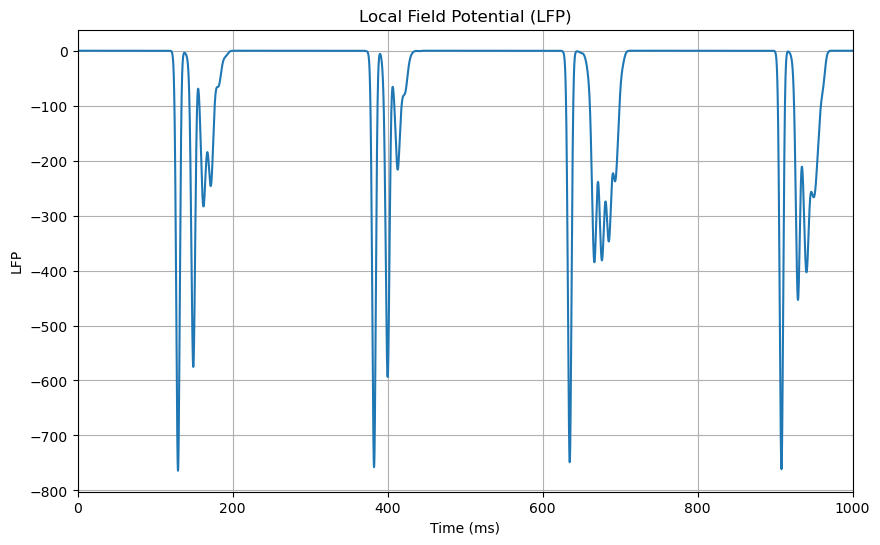

In [ ]:
from scipy.signal import welch
from scipy.signal.windows import hann

# ! This LFP can introduce gamma oscillations when summing exc. and inh. LFP, due to slgiht
# time delay in inhibitory response.

# * Start by summing the spikes in dt = 25ms bins
t = runner.mon['ts'].view()
# dt = 10.0
# n_bins = int(t[-1] / dt)
# allspikes = bp.math.sum(runner.mon['E.spike'], axis=1)

# # Group allspikes into dt ms bins, then sum in those bins
# bin_indices = (t / dt).astype(int)
# bin_indices = jnp.clip(bin_indices, 0, n_bins - 1)  # Ensure we stay within bounds
# spikes_binned = jnp.bincount(bin_indices, weights=allspikes, length=n_bins)

lfp = bp.measure.unitary_LFP(t, runner.mon['I.spike'].view(), 'inh', location='superficial layer')
# lfp = bp.measure.unitary_LFP(t, runner.mon['E.spike'].view(), 'exc', location='superficial layer')

# t_binned = jnp.arange(0, n_bins) * dt
# lfp = jnp.convolve(spikes_binned, hann(100), mode='same')
 # * Plot 'LFP'
plt.figure(figsize=(10, 6))
# plt.plot(spikes_binned)
plt.plot(t, lfp)
plt.xlabel('Time (ms)')
plt.ylabel('LFP')
plt.title('Local Field Potential (LFP)')
plt.grid(True)
plt.gca().set_xlim(0, 1000)
plt.show()



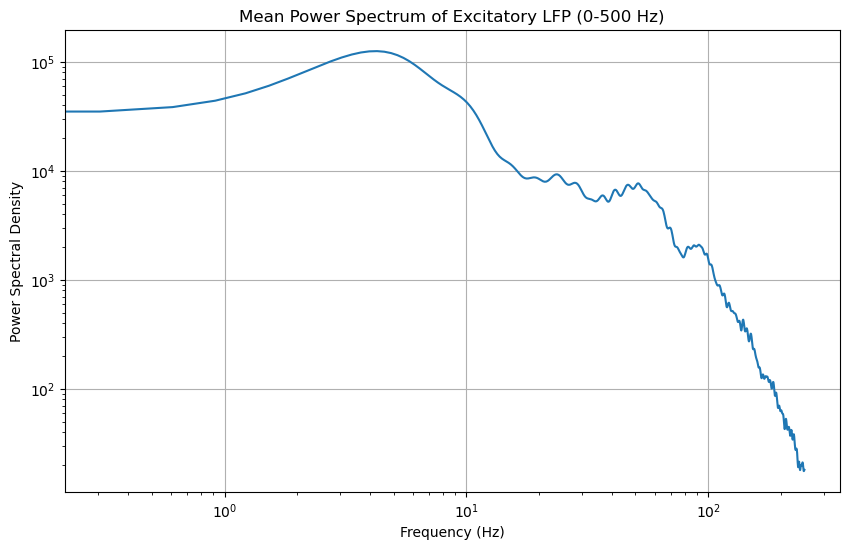

In [ ]:
# * Plot the mean power spectrum.
# Calculate a spectrum for each neuron, then average it

ts = t / 1000  # To seconds

# lfp = lfp - np.mean(lfp, axis=0)
# lfp = binned_prop_active
lfp = input

f, Pxx = welch(lfp, fs=1/(ts[1] - ts[0]), nperseg=4000, nfft=2048*16)

# Limit frequency range to 500 Hz
freq_mask = f <= 250
f_limited = f[freq_mask]
Pxx_limited = Pxx[freq_mask]

plt.figure(figsize=(10, 6))
plt.loglog(f_limited, Pxx_limited)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('Mean Power Spectrum of Excitatory LFP (0-500 Hz)')
plt.grid(True)
plt.show()

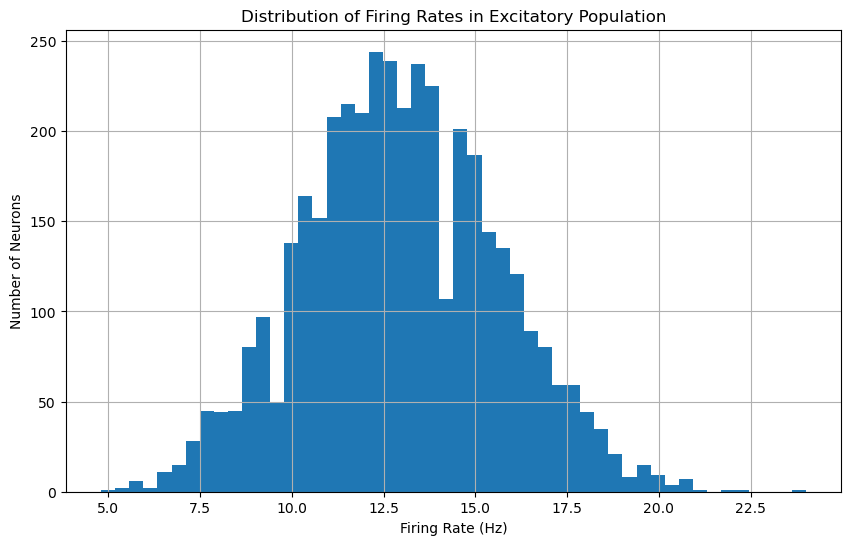

In [ ]:
# * Plot the distribution of firing rates by summing the total numebr of spikes over the
#   recording, divided byt he length of the recording
spikes = runner.mon['E.spike']
t = runner.mon['ts'].view()
T = t[-1] / 1000  # Duration in seconds
rates = np.sum(spikes, axis=0) / T

plt.figure(figsize=(10, 6))
plt.hist(rates, bins=50)
plt.xlabel('Firing Rate (Hz)')
plt.ylabel('Number of Neurons')
plt.title('Distribution of Firing Rates in Excitatory Population')
plt.grid(True)
plt.show()


In [ ]:

#! Uncomment to run, but takes a while
# nu_n_ext = range(1, 601, 10)
# out = FNSnet.estimate_filter_factor(nu_n_ext = nu_n_ext)

NameError: name 'nu_n_ext' is not defined

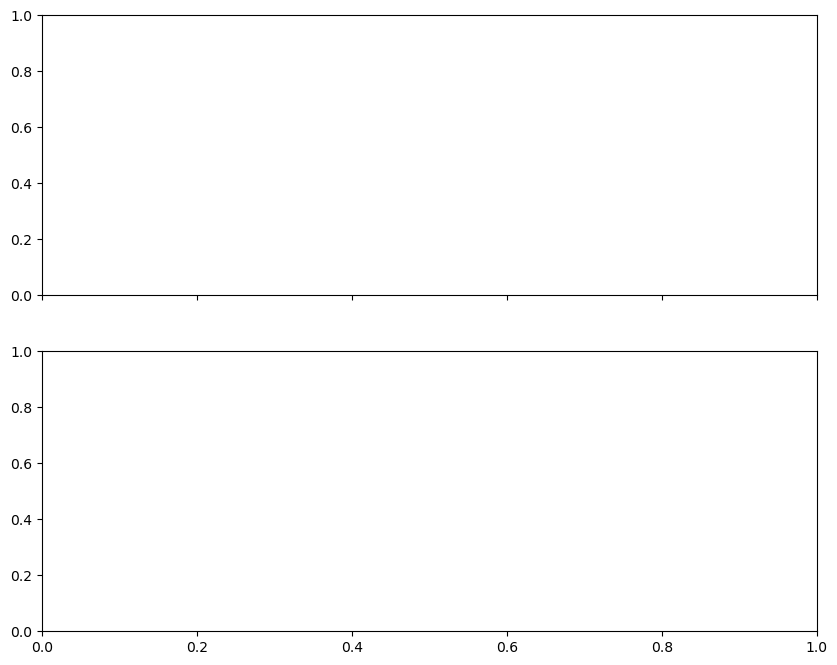

In [ ]:
# * Plot membrane potential (and SD as a band) as a function of nu*n_ext, for exc and inh in
#   different subplots
alpha = 0.1
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)
axs[0].plot(nu_n_ext, out['E']['mean'], label='Excitatory')
# * Add a light line either side of the mean for pm the first SD
axs[0].fill_between(nu_n_ext, out['E']['mean'] - out['E']['std'], out['E']['mean'] + out['E']['std'], alpha=0.1, color='cornflowerblue')
# * And another band for the 2nd sd, same color
axs[0].fill_between(nu_n_ext, out['E']['mean'] - 2*out['E']['std'], out['E']['mean'] + 2*out['E']['std'], alpha=0.1, color='cornflowerblue')
#and another for 3 SD
axs[0].fill_between(nu_n_ext, out['E']['mean'] - 3*out['E']['std'], out['E']['mean'] + 3*out['E']['std'], alpha=0.1, color='cornflowerblue')
# Add fainter grid lines (fainter than default)
axs[0].grid(True)
#Make grid lines fainter
axs[0].grid(alpha=alpha*2)

axs[0].set_title("Mean Membrane Potential")
axs[0].set_ylabel("Membrane Potential (mV)")
axs[0].legend()
# addd line for threshold
axs[0].axhline(FNSnet.E.V_th, color='black', linestyle='--', lw=1.5)

axs[1].plot(nu_n_ext, out['I']['mean'], label='Inhibitory', color='crimson')
axs[1].fill_between(nu_n_ext, out['I']['mean'] - out['I']['std'], out['I']['mean'] + out['I']['std'], alpha=0.1, color='crimson')
axs[1].fill_between(nu_n_ext, out['I']['mean'] - 2*out['I']['std'], out['I']['mean'] + 2*out['I']['std'], alpha=0.1, color='crimson')
axs[1].fill_between(nu_n_ext, out['I']['mean'] - 3*out['I']['std'], out['I']['mean'] + 3*out['I']['std'], alpha=0.1, color='crimson')
axs[1].grid(True)
axs[1].grid(alpha=alpha*2)

axs[1].set_xlabel("nu*n_ext")
axs[1].set_ylabel("Membrane Potential (mV)")
axs[1].legend()
axs[1].axhline(FNSnet.I.V_th, color='black', linestyle='--', lw=1.5)

plt.tight_layout()
plt.show()


In [ ]:
# * Do a linear regression to estimate the slope
from scipy.stats import linregress
m_e, b_e, r_e, p_e, se_e = linregress(nu_n_ext, out['E']['mean'])
print("Excitatory slope:", m_e)
m_i, b_i, r_i, p_i, se_i = linregress(nu_n_ext, out['I']['mean'])
print("Inhibitory slope:", m_i)

alpha_e = m_e / (FNSnet.J_e / FNSnet.E.g_L)
print("Excitatory filter factor:", alpha_e)
alpha_i = m_i / (FNSnet.J_e / FNSnet.I.g_L)
print("Inhibitory filter factor:", alpha_i)
